# Zero-Shot SSDU (ZS-SSL) 데모 — 단일 스캔 자기지도 복원

**ZS-SSL** = 학습셋 없이 **테스트 스캔 1장만으로** unrolled 네트워크를 학습한다.
획득 마스크 Ω를 다음처럼 쪼갠다:
- **Γ (validation)**: Ω에서 떼어낸 고정 holdout → early stopping용
- 나머지 **Ω\Γ**: 매 step마다 **Θ(데이터 일관성) / Λ(loss)** 로 다시 분할

각 step: Θ만 보고 복원 → **Λ 위치의 측정 k-space를 맞히도록** 학습. 검증 loss는 Γ에서.
최종 추론은 **전체 Ω**로 데이터 일관성. (fully-sampled GT는 학습에 안 씀, monitoring만)

In [1]:
import os, sys, time
sys.path.insert(0, '/home/sonwonjun/research/MRRecon/code')
import numpy as np, torch, glob
import matplotlib.pyplot as plt
from mrrecon.config import Config
from mrrecon.data.loaders import read_slice
from mrrecon.data.masks import undersampling_mask
from mrrecon.data.datasets import ZeroShotDataset
from mrrecon.models import build_unrolled
from mrrecon.losses import MixL1L2Loss
from mrrecon.metrics import rss_metrics
from mrrecon.core.common import center_crop
from mrrecon.core.inference import recon_unrolled

# --- small config so the demo trains in a couple minutes ---
cfg = Config(); cfg.tissue='knee'; cfg.device='cuda' if torch.cuda.is_available() else 'cpu'
cfg.model='ssdu'; cfg.nb_unroll_blocks=5; cfg.res_blocks=4; cfg.cg_iter=5; cfg.mu=0.05
cfg.acc_rate=4; cfg.acs_lines=24; cfg.mask_type='vds_lustig'; cfg.rho=0.4
cfg.zs_val_rho=0.2; cfg.zs_num_splits=8; cfg.lr=5e-4; cfg.epochs=40; cfg.zs_patience=15; cfg.seed=1234
dev = torch.device(cfg.device); print('device', dev)

# one test slice (has RSS GT for monitoring)
files = sorted(glob.glob('/mnt/d/research/MRRecon/knee/test/*.h5'))
sf = files[len(files)//2]
kspace, sens, rss = read_slice(sf, crop_size=cfg.crop_size)
H,W = kspace.shape[1:]
rng = np.random.default_rng(cfg.seed)
omega = undersampling_mask((H,W), cfg.acc_rate, cfg.acs_lines, cfg.mask_type, rng=rng, vds_power=cfg.vds_power)
print('slice', sf.split('/')[-1], '| kspace', kspace.shape, '| acc', cfg.acc_rate)

device cuda
slice file1001289_031.h5 | kspace (15, 320, 320) | acc 4


## 1. 마스크 분할: Ω → Γ(val) + (Θ,Λ)
`ZeroShotDataset`이 Ω에서 Γ를 떼고(`zs_val_rho`), 매 step Ω\Γ를 Θ/Λ로 재분할(`rho`)한다.

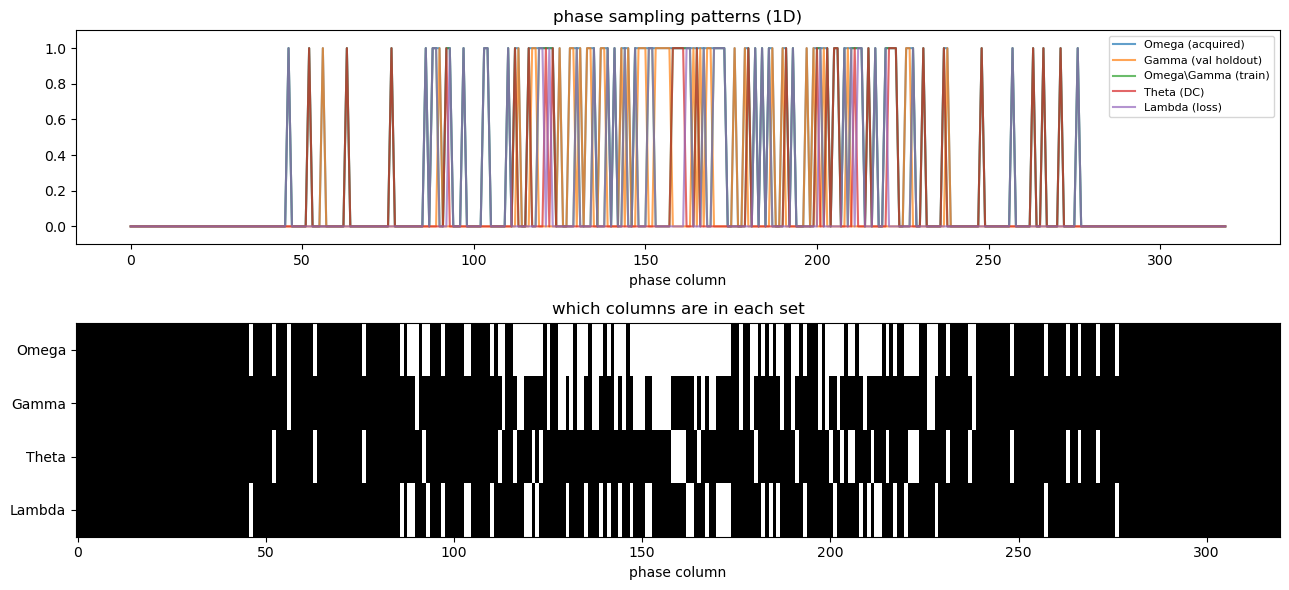

Omega sampled=109  Gamma=38  Theta=30  Lambda=41


In [2]:
ds = ZeroShotDataset(cfg, kspace, sens, omega)
b = ds[0]                                   # one (Theta, Lambda) realisation
theta = b['trn_mask'][0].numpy(); lam = b['loss_mask'][0].numpy()
gamma = ds.val_mask; train_portion = ds.train_mask
def line(m): return m[m.shape[0]//2]        # 1D phase pattern of a 2D mask
fig, ax = plt.subplots(2, 1, figsize=(13, 6))
for nm, m in [('Omega (acquired)', omega), ('Gamma (val holdout)', gamma),
              ('Omega\\Gamma (train)', train_portion), ('Theta (DC)', theta), ('Lambda (loss)', lam)]:
    ax[0].plot(line(m), label=nm, alpha=0.7)
ax[0].set_title('phase sampling patterns (1D)'); ax[0].legend(fontsize=8); ax[0].set_xlabel('phase column'); ax[0].set_ylim(-0.1,1.1)
ax[1].imshow(np.stack([line(omega), line(gamma), line(theta), line(lam)]), aspect='auto', cmap='gray', interpolation='nearest')
ax[1].set_yticks(range(4)); ax[1].set_yticklabels(['Omega','Gamma','Theta','Lambda']); ax[1].set_xlabel('phase column'); ax[1].set_title('which columns are in each set')
plt.tight_layout(); plt.show()
print(f'Omega sampled={int(line(omega).sum())}  Gamma={int(line(gamma).sum())}  Theta={int(line(theta).sum())}  Lambda={int(line(lam).sum())}')

## 2. unrolled 네트워크 + 옵티마이저
`UnrolledSSDU` = ResNet denoiser + CG 데이터 일관성, `nb_unroll_blocks`회 반복.

In [3]:
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
model = build_unrolled(cfg).to(dev)
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
loss_fn = MixL1L2Loss().to(dev)
nparam = sum(p.numel() for p in model.parameters())
print(f'model={cfg.model}  params={nparam/1e3:.1f}k  unroll={cfg.nb_unroll_blocks} res_blocks={cfg.res_blocks} cg_iter={cfg.cg_iter}')

model=ssdu  params=334.1k  unroll=5 res_blocks=4 cg_iter=5


## 3. ZS-SSL 학습 루프 (단일 스캔)
매 epoch: Ω\Γ를 Θ/Λ로 여러 번 재분할 → Λ k-space loss로 학습. 검증 loss는 Γ에서. best(val) 추적 + early stop.
중간 epoch의 복원도 저장해 수렴 과정을 본다.

In [4]:
from torch.utils.data import DataLoader
dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)
def to_dev(b): return (b['x_in'].to(dev), b['sens_maps'].to(dev), b['ref_kspace'].to(dev), b['trn_mask'].to(dev), b['loss_mask'].to(dev))

@torch.no_grad()
def val_loss():
    model.eval(); vb={k:(v.unsqueeze(0) if torch.is_tensor(v) else v) for k,v in ds.val_sample().items()}
    x,s,rk,tr,lm = to_dev(vb); _,_,nw = model(x,s,tr,lm); return loss_fn(nw,rk).item()

@torch.no_grad()
def full_recon():
    _,_,rec = recon_unrolled(model, kspace, sens, omega, dev); return rec

hist=[]; best_val=1e9; best_state=None; since=0; snaps={}
t0=time.time()
for ep in range(cfg.epochs):
    model.train(); el=0; n=0
    for b in dl:
        x,s,rk,tr,lm = to_dev(b)
        _,_,nw = model(x,s,tr,lm); loss = loss_fn(nw,rk)
        opt.zero_grad(); loss.backward(); opt.step(); el+=loss.item(); n+=1
    el/=n; vl=val_loss(); rec=full_recon(); m=rss_metrics(rss,rec,crop_fn=center_crop)
    hist.append({'ep':ep+1,'train':el,'val':vl,'ssim':m['ssim'],'psnr':m['psnr']})
    if ep+1 in (1,5,15,cfg.epochs): snaps[ep+1]=np.abs(rec)
    if vl<best_val: best_val=vl; best_state={k:v.detach().clone() for k,v in model.state_dict().items()}; since=0
    else: since+=1
    if (ep+1)%5==0 or ep==0: print(f'ep{ep+1:3d} train={el:.4f} val={vl:.4f} ssim={m["ssim"]:.4f} psnr={m["psnr"]:.2f}')
    if since>=cfg.zs_patience: print(f'early stop @ ep{ep+1}'); break
print(f'done in {time.time()-t0:.1f}s, best val={best_val:.4f}')

ep  1 train=0.6435 val=0.4741 ssim=0.8086 psnr=31.01


ep  5 train=0.6312 val=0.4703 ssim=0.8157 psnr=31.09


ep 10 train=0.6168 val=0.4688 ssim=0.8176 psnr=31.00


ep 15 train=0.6151 val=0.4668 ssim=0.8172 psnr=30.96


ep 20 train=0.6072 val=0.4674 ssim=0.8149 psnr=30.86


ep 25 train=0.6089 val=0.4681 ssim=0.8143 psnr=30.85


ep 30 train=0.6025 val=0.4666 ssim=0.8142 psnr=30.87


ep 35 train=0.6008 val=0.4668 ssim=0.8132 psnr=30.80


ep 40 train=0.5966 val=0.4669 ssim=0.8140 psnr=30.84
done in 93.2s, best val=0.4644


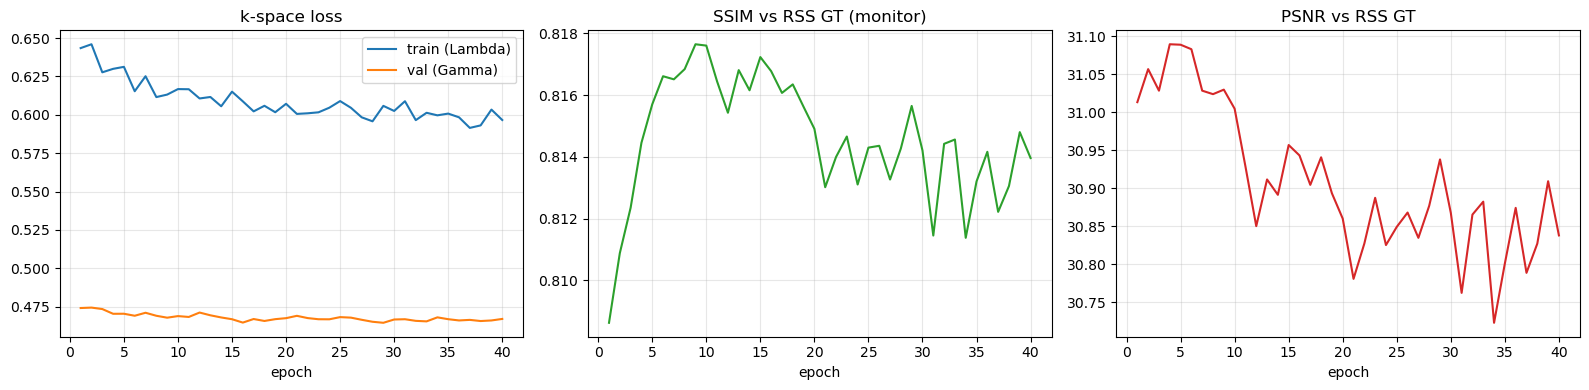

In [5]:
ep=[h['ep'] for h in hist]
fig,ax=plt.subplots(1,3,figsize=(16,4))
ax[0].plot(ep,[h['train'] for h in hist],label='train (Lambda)'); ax[0].plot(ep,[h['val'] for h in hist],label='val (Gamma)')
ax[0].set_title('k-space loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep,[h['ssim'] for h in hist],'C2'); ax[1].set_title('SSIM vs RSS GT (monitor)'); ax[1].set_xlabel('epoch'); ax[1].grid(alpha=0.3)
ax[2].plot(ep,[h['psnr'] for h in hist],'C3'); ax[2].set_title('PSNR vs RSS GT'); ax[2].set_xlabel('epoch'); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 최종 복원 (best 모델, 전체 Ω 데이터 일관성) vs GT

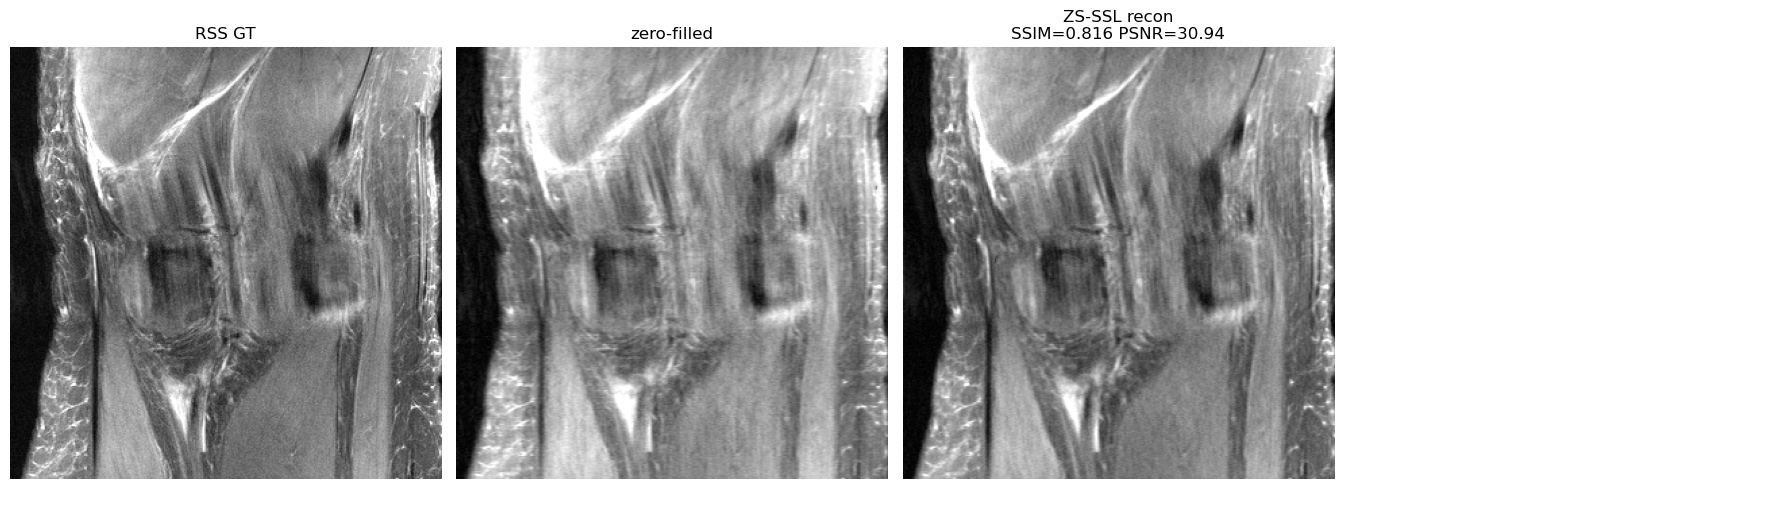

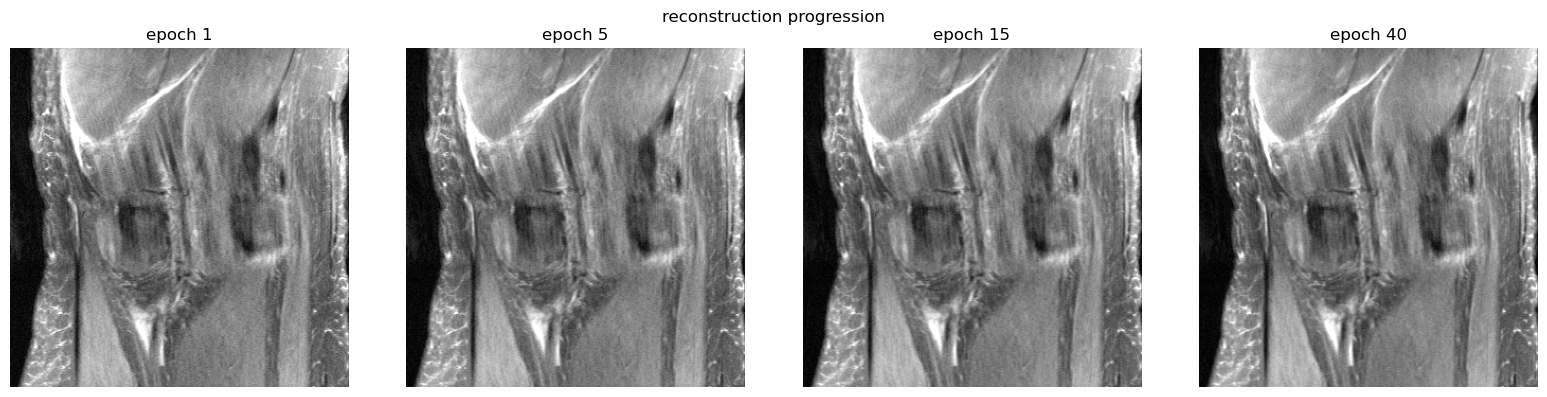

final ZS-SSL: SSIM=0.8156 PSNR=30.938 NMSE=0.00813


In [6]:
model.load_state_dict(best_state)
rec = full_recon(); m = rss_metrics(rss, rec, crop_fn=center_crop)
zf = recon_unrolled(model, kspace, sens, omega, dev)[1]   # zero-filled SENSE (ref)
rc = center_crop(np.abs(rec)); rssc = center_crop(rss); zfc=center_crop(np.abs(zf))
from mrrecon.metrics import match_scale
fig,ax=plt.subplots(1,4,figsize=(18,5))
ax[0].imshow(rssc,cmap='gray',vmax=0.6*rssc.max()); ax[0].set_title('RSS GT'); ax[0].axis('off')
ax[1].imshow(zfc,cmap='gray',vmax=0.6*zfc.max()); ax[1].set_title('zero-filled'); ax[1].axis('off')
ax[2].imshow(match_scale(rssc,rc),cmap='gray',vmax=0.6*rssc.max()); ax[2].set_title(f'ZS-SSL recon\nSSIM={m["ssim"]:.3f} PSNR={m["psnr"]:.2f}'); ax[2].axis('off')
# recon progression snapshots
ax[3].axis('off')
plt.tight_layout(); plt.show()
# convergence snapshots
fig,axx=plt.subplots(1,len(snaps),figsize=(4*len(snaps),4))
for a,(e,im) in zip(np.atleast_1d(axx),sorted(snaps.items())):
    a.imshow(match_scale(rss,im) if im.shape==rss.shape else im,cmap='gray',vmax=0.6*rss.max()); a.set_title(f'epoch {e}'); a.axis('off')
plt.suptitle('reconstruction progression'); plt.tight_layout(); plt.show()
print(f'final ZS-SSL: SSIM={m["ssim"]:.4f} PSNR={m["psnr"]:.3f} NMSE={m["nmse"]:.5f}')

**요약**
- 학습셋 없이 **단일 스캔**으로 학습 (Ω→Γ + 매 step Θ/Λ 재분할, Λ k-space loss, Γ로 early stop)
- 최종 추론은 **전체 Ω** 데이터 일관성
- RSS GT는 monitoring만 (학습엔 안 씀)
- 실제 실행: `python -m mrrecon.zero_shot --algo zsssl --tissue knee --split test`